# 02 · Baseline — Waste Classifier

**Modelo:** EfficientNetB0 frozen + cabeza clasificadora  

| Funcionalidad | Implementación |
|---|---|
| GPU Colab o local/WSL | Auto-detección + `CUDA_VISIBLE_DEVICES` |
| Reanudar tras desconexión | `initial_epoch` + CSV acumulativo |
| Regenerar métricas sin reentrenar | Bloque 6 autónomo |
| Re-ejecución segura | Fingerprint MD5 del experimento |


---
## 🌎 Bloque 0 — Setup universal

**Ejecutar siempre primero.** Configura entorno, GPU, rutas y fingerprint.

In [ ]:
import os

# ── GPU: seleccionar RTX antes de importar TensorFlow ──
# Colab tiene una sola GPU → CUDA_VISIBLE_DEVICES no es necesario
# Local/WSL con Intel + NVIDIA → forzar NVIDIA
import sys
IN_COLAB = 'google.colab' in sys.modules

if not IN_COLAB:
    os.environ['CUDA_VISIBLE_DEVICES'] = '0'
    print('💻 Local/WSL — forzando GPU 1 (RTX 2060)')
else:
    print('🌐 Colab — usando GPU disponible')

# ── Imports ──
import json
import hashlib
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

import tensorflow as tf

# ── Verificar GPU ──
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'✅ GPU: {gpus[0].name}')
else:
    print('⚠️  Sin GPU — Colab: Runtime')

# ── Rutas según entorno ──
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = Path('/content/drive/MyDrive/waste_classifier')
else:
    BASE = Path('../../').resolve()   # fallback local

SRC_DIR    = BASE / 'src'
SPLIT_DIR  = BASE / 'data' / 'splits'
LOGS_DIR   = BASE / 'logs'
MODELS_DIR = BASE / 'models'
for d in [LOGS_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Importar data_pipeline (limpiando caché siempre) ──
for mod in list(sys.modules.keys()):
    if 'data_pipeline' in mod:
        del sys.modules[mod]

sys.path = [p for p in sys.path if str(SRC_DIR) not in p]
sys.path.insert(0, str(SRC_DIR))

from data_pipeline import (
    build_dataset, get_class_weights,
    build_global_augmentation_layer,
    CLASSES, CLASS_TO_IDX, IDX_TO_CLASS, IMG_SIZE
)
print('✅ data_pipeline importado')

# ── Hiperparámetros ──
HP = {
    'batch_size'    : 32,
    'epochs_frozen' : 20,      # 20 epochs con normalización correcta
    'lr_frozen'     : 1e-3,
    'dropout_1'     : 0.3,
    'dropout_2'     : 0.2,
    'dense_units'   : 256,
    'architecture'  : 'EfficientNetB0',
    'seed'          : 42,
    'normalizacion' : 'backbone_interno',   # documentar qué normalización se usó
}

tf.random.set_seed(HP['seed'])
np.random.seed(HP['seed'])

# ── Fingerprint del experimento ───────────────────────────────
# Mismo fingerprint = mismos datos + mismos HP = no reentrenar
def compute_fingerprint(split_dir, hyperparams):
    h = hashlib.md5()
    train_csv = split_dir / 'train.csv'
    if train_csv.exists():
        with open(train_csv, 'rb') as f:
            h.update(f.read())
    h.update(json.dumps(hyperparams, sort_keys=True).encode())
    return h.hexdigest()[:12]

FINGERPRINT     = compute_fingerprint(SPLIT_DIR, HP)
RUN_ID          = f'baseline_{FINGERPRINT}'
RUN_DIR         = LOGS_DIR / RUN_ID
RUN_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = str(MODELS_DIR / f'{RUN_ID}_best.keras')
FINAL_PATH      = str(MODELS_DIR / f'{RUN_ID}_final.keras')

print(f'\n✅ Setup completo')
print(f'   Entorno     : {"Colab" if IN_COLAB else "Local/WSL"}')
print(f'   BASE        : {BASE}')
print(f'   Fingerprint : {FINGERPRINT}')
print(f'   RUN_ID      : {RUN_ID}')
print(f'   Epochs      : {HP["epochs_frozen"]}')
print(f'   Normaliz.   : {HP["normalizacion"]}')

💻 Local/WSL — forzando GPU 1 (RTX 2060)


2026-03-19 10:25:06.956489: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/under/miniconda3/envs/py310/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


✅ GPU: /physical_device:GPU:0
✅ data_pipeline importado

✅ Setup completo
   Entorno     : Local/WSL
   BASE        : /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5
   Fingerprint : e96de0c723f2
   RUN_ID      : baseline_e96de0c723f2
   Epochs      : 20
   Normaliz.   : manual_127.5


---
## 📇 Bloque 1 — Cargar datos y verificar normalización

Verifica shape **y** rango.

In [ ]:

train_ds = build_dataset(
    SPLIT_DIR / 'train.csv', split='train',
    batch_size=HP['batch_size'], augment='global'
)
val_ds = build_dataset(
    SPLIT_DIR / 'val.csv', split='val',
    batch_size=HP['batch_size'], augment=None
)
class_weights = get_class_weights(LOGS_DIR / 'class_weights.json')

# ── Verificar shape Y rango ──
print('\n📐 Verificando datos...')
for images, labels in train_ds.take(1):
    assert images.shape[1:] == (224, 224, 3), \
        f'ERROR shape: {images.shape[1:]}'
    assert images.dtype == tf.float32, \
        f'ERROR dtype: {images.dtype}'

    img_min = float(images.numpy().min())
    img_max = float(images.numpy().max())

    print(f'  Shape     : {images.shape}')
    print(f'  dtype     : {images.dtype}')
    print(f'  rango     : [{img_min:.3f}, {img_max:.3f}]')

    # Verificación crítica — detiene si el rango es incorrecto
    if img_max > 100:
        print('  normaliz. : ✅ [0, 255] — EfficientNetB0 normaliza internamente')
    elif img_max <= 1.1 and img_max > 0.1:
        raise ValueError(
            '❌ Doble normalización detectada\n'
            '   El pipeline está normalizando a [-1,1] antes del modelo\n'
            '   → Elimina el paso normalize_image de build_dataset()'
        )
    else:
        raise ValueError(f'❌ Rango inesperado [{img_min:.3f}, {img_max:.3f}]')

print('\n✅ Datos verificados — listo para entrenar')

[build_dataset] split='train' | 7644 imágenes | batch_size=32 | augment=global


I0000 00:00:1773912311.310383   16747 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4055 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:01:00.0, compute capability: 7.5


[build_dataset] split='val' | 1639 imágenes | batch_size=32 | augment=None
[get_class_weights] Pesos cargados:
  0 · vidrio          → 0.6386
  1 · plastico        → 0.8722
  2 · metal           → 1.0018
  3 · papel           → 1.0065
  4 · organico        → 1.1177
  5 · carton          → 1.1543
  6 · no_reciclable   → 1.8699

📐 Verificando datos...
  Shape     : (32, 224, 224, 3)
  dtype     : <dtype: 'float32'>
  rango     : [0.000, 255.000]
  normaliz. : ✅ [0, 255] — EfficientNetB0 normaliza internamente

✅ Datos verificados — listo para entrenar


2026-03-19 10:25:13.261514: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


---
## 🏗️ Bloque 2 — Construir modelo

In [ ]:
def build_baseline_model(hp):
    backbone = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(*IMG_SIZE, 3)
    )
    backbone.trainable = False

    inputs  = tf.keras.Input(shape=(*IMG_SIZE, 3), name='input_image')
    x       = backbone(inputs, training=False)
    x       = tf.keras.layers.GlobalAveragePooling2D(name='gap')(x)
    x       = tf.keras.layers.BatchNormalization(name='bn_head')(x)
    x       = tf.keras.layers.Dropout(hp['dropout_1'], seed=hp['seed'], name='dropout_1')(x)
    x       = tf.keras.layers.Dense(hp['dense_units'], activation='relu', name='dense_head')(x)
    x       = tf.keras.layers.Dropout(hp['dropout_2'], seed=hp['seed'], name='dropout_2')(x)
    outputs = tf.keras.layers.Dense(len(CLASSES), activation='softmax', name='output')(x)

    model = tf.keras.Model(inputs, outputs, name='waste_classifier_baseline')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp['lr_frozen']),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_accuracy')
        ]
    )
    return model


# ── Seleccionar dispositivo ──
# OneDeviceStrategy fuerza el modelo al dispositivo correcto
# En Colab: /gpu:0 (única GPU); En WSL con RTX + Intel
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    device = '/gpu:0'
    print(f'✅ Usando GPU: {gpus[0].name}')
else:
    device = '/cpu:0'
    print('⚠️  Usando CPU — entrenamiento lento')

strategy = tf.distribute.OneDeviceStrategy(device=device)

# ── Cargar checkpoint o construir desde cero ──
with strategy.scope():
    if Path(CHECKPOINT_PATH).exists():
        print(f'♻️  Checkpoint encontrado — cargando modelo')
        model = tf.keras.models.load_model(CHECKPOINT_PATH)
        print('✅ Modelo cargado desde checkpoint')
    else:
        print('🆕 Sin checkpoint — construyendo desde cero')
        model = build_baseline_model(HP)
        print('✅ Modelo construido')

total     = model.count_params()
trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f'\n  Total params      : {total:>10,}')
print(f'  Entrenables       : {trainable:>10,}  ← cabeza clasificadora')
print(f'  Congelados        : {total-trainable:>10,}  ← EfficientNetB0')

🆕 Sin checkpoint — construyendo desde cero


✅ Modelo construido

  Total params      :  4,384,426
  Entrenables       :    332,295  ← cabeza clasificadora
  Congelados        :  4,052,131  ← EfficientNetB0


---
## Bloque 3 — Callbacks

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor='val_accuracy', save_best_only=True,
        save_weights_only=False, mode='max', verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, mode='max', verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3,
        patience=3, min_lr=1e-7, verbose=1
    ),
    # append=True → acumula epochs si se reanuda tras desconexión
    tf.keras.callbacks.CSVLogger(
        str(RUN_DIR / 'training_log.csv'),
        separator=',', append=True
    ),
]
print('✅ Callbacks configurados')
for cb in callbacks:
    print(f'  · {type(cb).__name__}')

✅ Callbacks configurados
  · ModelCheckpoint
  · EarlyStopping
  · ReduceLROnPlateau
  · CSVLogger


---
## Bloque 4 — Entrenamiento inteligente

| Caso | Condición | Acción |
|---|---|---|
| 1 | `run_summary.json` existe | Salta entrenamiento — carga resultados |
| 2 | CSV parcial + checkpoint | Reanuda desde epoch N |
| 3 | Sin nada | Entrena desde cero |

In [ ]:
def epochs_completados(run_dir):
    log = run_dir / 'training_log.csv'
    if not log.exists():
        return 0
    try:
        return len(pd.read_csv(log))
    except Exception:
        return 0

def entrenamiento_completo(run_dir):
    return (run_dir / 'run_summary.json').exists()

# ── Diagnóstico ──
epochs_done = epochs_completados(RUN_DIR)
completo    = entrenamiento_completo(RUN_DIR)

print('=' * 55)
print('  DIAGNÓSTICO')
print('=' * 55)
print(f'  Fingerprint        : {FINGERPRINT}')
print(f'  Epochs completados : {epochs_done} / {HP["epochs_frozen"]}')
print(f'  Completo           : {completo}')
print(f'  Checkpoint existe  : {Path(CHECKPOINT_PATH).exists()}')

if completo:
    # ── CASO 1: ya terminó ──
    print('\n✅ CASO 1: Entrenamiento ya completado — cargando resultados')
    with open(RUN_DIR / 'run_summary.json') as f:
        run_summary = json.load(f)
    best_val_acc = run_summary['best_val_accuracy']
    overfitting  = run_summary['overfitting']
    history_frozen = None
    print(f'  Val accuracy : {best_val_acc:.4f}')
    print(f'  Overfitting  : {overfitting*100:.2f}%')
    print('  → Ejecuta Bloque 5 o 6 directamente')

elif epochs_done > 0:
    # ── CASO 2: reanudación ──
    print(f'\n♻️  CASO 2: Reanudando desde epoch {epochs_done}')
    history_frozen = model.fit(
        train_ds, validation_data=val_ds,
        epochs=HP['epochs_frozen'],
        initial_epoch=epochs_done,
        class_weight=class_weights,
        callbacks=callbacks, verbose=1
    )

else:
    # ── CASO 3: desde cero ──
    print(f'\n🚀 CASO 3: Entrenando desde cero — {HP["epochs_frozen"]} epochs')
    history_frozen = model.fit(
        train_ds, validation_data=val_ds,
        epochs=HP['epochs_frozen'],
        initial_epoch=0,
        class_weight=class_weights,
        callbacks=callbacks, verbose=1
    )

# ── Guardar resumen si acaba de terminar ──
if not completo and 'history_frozen' in dir() and history_frozen is not None:
    df_log       = pd.read_csv(RUN_DIR / 'training_log.csv')
    best_val_acc = float(df_log['val_accuracy'].max())
    best_epoch   = int(df_log['val_accuracy'].idxmax()) + 1
    final_acc    = float(df_log['accuracy'].iloc[-1])
    overfitting  = float(final_acc - best_val_acc)

    run_summary = {
        'run_id'              : RUN_ID,
        'fingerprint'         : FINGERPRINT,
        'fase'                : 'frozen',
        'epochs_ejecutados'   : int(len(df_log)),
        'epochs_max'          : HP['epochs_frozen'],
        'hyperparams'         : HP,
        'best_val_accuracy'   : best_val_acc,
        'best_epoch'          : best_epoch,
        'train_accuracy_final': final_acc,
        'overfitting'         : overfitting,
        'checkpoint_path'     : CHECKPOINT_PATH,
        'fecha_completado'    : datetime.now().strftime('%Y-%m-%d %H:%M')
    }
    with open(RUN_DIR / 'run_summary.json', 'w') as f:
        json.dump(run_summary, f, indent=2)

    model.save(FINAL_PATH)

    print('\n' + '=' * 55)
    print('  RESULTADOS')
    print('=' * 55)
    print(f'  Val accuracy : {best_val_acc:.4f}  (epoch {best_epoch})')
    print(f'  Train acc    : {final_acc:.4f}')
    print(f'  Overfitting  : {overfitting*100:.2f}%')
    flag = '✅ cumplida' if overfitting < 0.05 else '⚠️  revisar'
    print(f'  Rúbrica <5%  : {flag}')
    print(f'  Modelo       : {FINAL_PATH}')
    print('=' * 55)

  DIAGNÓSTICO
  Fingerprint        : e96de0c723f2
  Epochs completados : 0 / 20
  Completo           : False
  Checkpoint existe  : False

🚀 CASO 3: Entrenando desde cero — 20 epochs
Epoch 1/20


E0000 00:00:1773912326.522285   16747 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/waste_classifier_baseline_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-03-19 10:25:29.530351: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700


239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.6550 - loss: 1.0488 - top3_accuracy: 0.8909

2026-03-19 10:26:18.150635: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node MultiDeviceIteratorGetNextFromShard}}]]
	 [[RemoteCall]]
2026-03-19 10:26:26.234219: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node MultiDeviceIteratorGetNextFromShard}}]]
	 [[RemoteCall]]



Epoch 1: val_accuracy improved from None to 0.87309, saving model to /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5/models/baseline_e96de0c723f2_best.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 67s 233ms/step - accuracy: 0.7463 - loss: 0.7673 - top3_accuracy: 0.9418 - val_accuracy: 0.8731 - val_loss: 0.3642 - val_top3_accuracy: 0.9841 - learning_rate: 0.0010
Epoch 2/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.8447 - loss: 0.4259 - top3_accuracy: 0.9817
Epoch 2: val_accuracy improved from 0.87309 to 0.88774, saving model to /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5/models/baseline_e96de0c723f2_best.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 61s 253ms/step - accuracy: 0.8431 - loss: 0.4411 - top3_accuracy: 0.9795 - val_accuracy: 0.8877 - val_loss: 0.3348 - val_top3_accuracy: 0.9854 - learning_rate: 0.0010
Epoch 3/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.8580 - loss: 0.3794 - top3_accuracy: 0.9848

...


Epoch 3: val_accuracy did not improve from 0.88774
239/239 ━━━━━━━━━━━━━━━━━━━━ 65s 270ms/step - accuracy: 0.8615 - loss: 0.3744 - top3_accuracy: 0.9852 - val_accuracy: 0.8853 - val_loss: 0.3276 - val_top3_accuracy: 0.9860 - learning_rate: 0.0010
Epoch 4/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.8881 - loss: 0.3157 - top3_accuracy: 0.9906
Epoch 4: val_accuracy improved from 0.88774 to 0.90421, saving model to /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5/models/baseline_e96de0c723f2_best.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 69s 288ms/step - accuracy: 0.8795 - loss: 0.3302 - top3_accuracy: 0.9893 - val_accuracy: 0.9042 - val_loss: 0.2856 - val_top3_accuracy: 0.9878 - learning_rate: 0.0010
Epoch 5/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.8985 - loss: 0.2838 - top3_accuracy: 0.9895
Epoch 5: val_accuracy did not improve from 0.90421
239/239 ━━━━━━━━━━━━━━━━━━━━ 71s 294ms/step - accuracy: 0.8968 - loss: 0.2771 - top3_accurac

2026-03-19 10:32:00.315999: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node MultiDeviceIteratorGetNextFromShard}}]]
	 [[RemoteCall]]



Epoch 6: val_accuracy improved from 0.90421 to 0.90604, saving model to /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5/models/baseline_e96de0c723f2_best.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 74s 309ms/step - accuracy: 0.9028 - loss: 0.2566 - top3_accuracy: 0.9948 - val_accuracy: 0.9060 - val_loss: 0.2963 - val_top3_accuracy: 0.9884 - learning_rate: 0.0010
Epoch 7/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.9089 - loss: 0.2404 - top3_accuracy: 0.9924
Epoch 7: val_accuracy improved from 0.90604 to 0.90848, saving model to /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5/models/baseline_e96de0c723f2_best.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 77s 321ms/step - accuracy: 0.9036 - loss: 0.2529 - top3_accuracy: 0.9923 - val_accuracy: 0.9085 - val_loss: 0.2936 - val_top3_accuracy: 0.9908 - learning_rate: 0.0010
Epoch 8/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.9154 - loss: 0.2273 - top3_accuracy: 0.9939
Epoch

2026-03-19 10:38:46.639025: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: CANCELLED: GetNextFromShard was cancelled
	 [[{{node MultiDeviceIteratorGetNextFromShard}}]]
	 [[RemoteCall]] [type.googleapis.com/tensorflow.DerivedStatus='']



Epoch 11: val_accuracy improved from 0.91336 to 0.92068, saving model to /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5/models/baseline_e96de0c723f2_best.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 85s 351ms/step - accuracy: 0.9263 - loss: 0.1909 - top3_accuracy: 0.9957 - val_accuracy: 0.9207 - val_loss: 0.2761 - val_top3_accuracy: 0.9908 - learning_rate: 0.0010
Epoch 12/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.9300 - loss: 0.1737 - top3_accuracy: 0.9973
Epoch 12: val_accuracy improved from 0.92068 to 0.92251, saving model to /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5/models/baseline_e96de0c723f2_best.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 93s 388ms/step - accuracy: 0.9301 - loss: 0.1806 - top3_accuracy: 0.9969 - val_accuracy: 0.9225 - val_loss: 0.2493 - val_top3_accuracy: 0.9921 - learning_rate: 0.0010
Epoch 13/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.9400 - loss: 0.1525 - top3_accuracy: 0.9980
E

---
## Bloque 5 — Curvas de entrenamiento

Siempre lee desde el CSV — funciona en cualquier sesión.

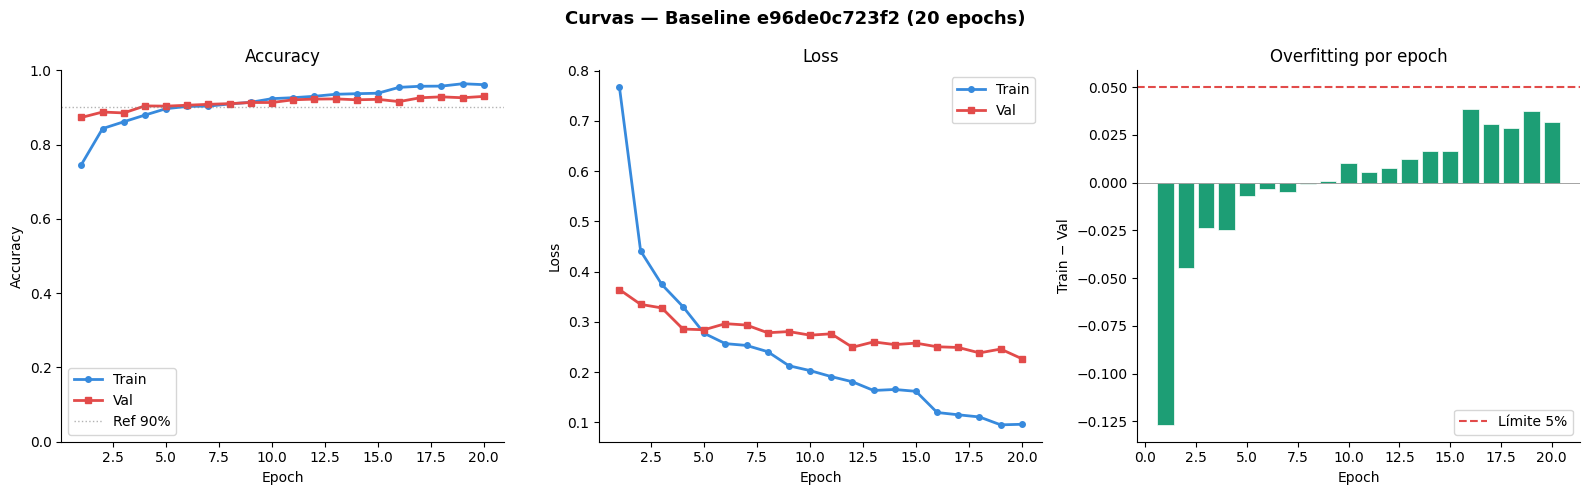

✅ Curvas guardadas — 20 epochs


In [ ]:
import matplotlib.pyplot as plt

log_file = RUN_DIR / 'training_log.csv'
if not log_file.exists():
    print('⚠️  Sin training_log.csv — ejecuta el Bloque 4 primero')
else:
    df_log = pd.read_csv(log_file)
    epochs = range(1, len(df_log) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Curvas — Baseline {FINGERPRINT} ({len(df_log)} epochs)',
                 fontsize=13, fontweight='bold')

    # Accuracy
    axes[0].plot(epochs, df_log['accuracy'],     '#378ADD', marker='o', ms=4, lw=2, label='Train')
    axes[0].plot(epochs, df_log['val_accuracy'], '#E24B4A', marker='s', ms=4, lw=2, label='Val')
    axes[0].axhline(0.90, color='gray', ls=':', lw=1, alpha=0.6, label='Ref 90%')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Accuracy'); axes[0].legend()
    axes[0].set_ylim(0, 1)
    axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

    # Loss
    axes[1].plot(epochs, df_log['loss'],     '#378ADD', marker='o', ms=4, lw=2, label='Train')
    axes[1].plot(epochs, df_log['val_loss'], '#E24B4A', marker='s', ms=4, lw=2, label='Val')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].set_title('Loss'); axes[1].legend()
    axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

    # Overfitting
    overfit    = df_log['accuracy'] - df_log['val_accuracy']
    bar_colors = ['#E24B4A' if v > 0.05 else '#1D9E75' for v in overfit]
    axes[2].bar(epochs, overfit, color=bar_colors, edgecolor='white', lw=0.5)
    axes[2].axhline(0.05, color='#E24B4A', ls='--', lw=1.5, label='Límite 5%')
    axes[2].axhline(0.00, color='gray', ls='-', lw=0.5)
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Train − Val')
    axes[2].set_title('Overfitting por epoch'); axes[2].legend()
    axes[2].spines['top'].set_visible(False); axes[2].spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(RUN_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Curvas guardadas — {len(df_log)} epochs')

---
## Bloque 6 — Evaluación independiente

**Solo necesita el Bloque 0.** Cargamos el modelo desde disco y generamos todas las métricas.
Solo lo usamos cuando se quieran regenerar métricas sin reentrenar.

📂 Cargando: baseline_e96de0c723f2_best.keras
✅ Modelo cargado
[build_dataset] split='val' | 1639 imágenes | batch_size=32 | augment=None

Generando predicciones...

📊 Classification Report (val):
─────────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

       vidrio     0.9638    0.9428    0.9532       367
     plastico     0.8938    0.9104    0.9020       268
        metal     0.8954    0.9145    0.9049       234
        papel     0.9181    0.9181    0.9181       232
     organico     0.9857    0.9857    0.9857       210
       carton     0.8894    0.9113    0.9002       203
no_reciclable     0.9746    0.9200    0.9465       125

     accuracy                         0.9298      1639
    macro avg     0.9315    0.9290    0.9301      1639
 weighted avg     0.9305    0.9298    0.9301      1639

✅ classification_report.txt guardado


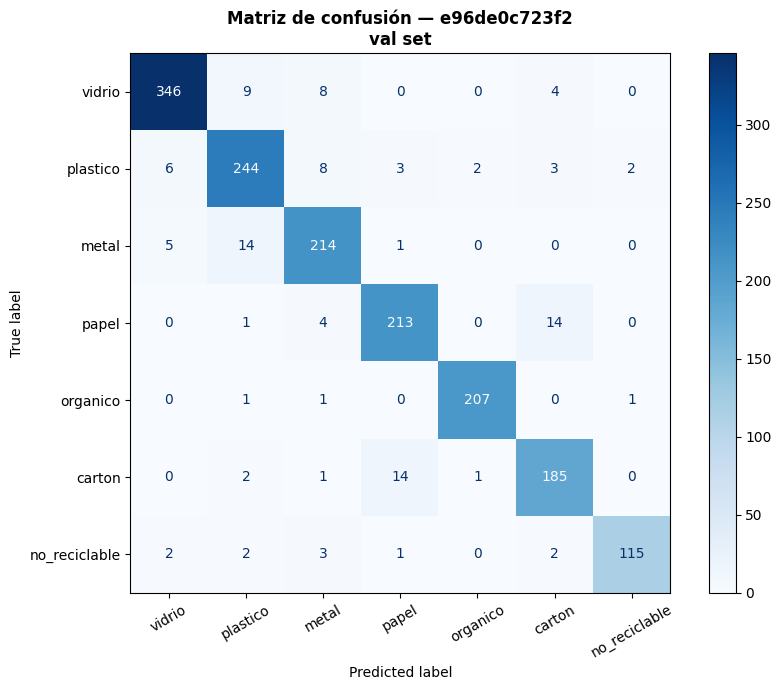

✅ confusion_matrix.png guardado

🔍 Confusiones más frecuentes (top 5):
  metal           → plastico          14 veces  (6.0%)
  papel           → carton            14 veces  (6.0%)
  carton          → papel             14 veces  (6.9%)
  vidrio          → plastico           9 veces  (2.5%)
  vidrio          → metal              8 veces  (2.2%)

  RESUMEN BASELINE
  Fingerprint  : e96de0c723f2
  Val accuracy : 0.9298
  Overfitting  : 3.16%  ✅
  Artefactos   : /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5/logs/baseline_e96de0c723f2
  → Siguiente  : 03_experiments.ipynb — fine-tuning


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# ── Cargar modelo desde disco ──
model_eval = None
for path in [CHECKPOINT_PATH, FINAL_PATH]:
    if Path(path).exists():
        print(f'📂 Cargando: {Path(path).name}')
        model_eval = tf.keras.models.load_model(path)
        print('✅ Modelo cargado')
        break

if model_eval is None:
    print(f'❌ No hay modelo para fingerprint {FINGERPRINT}')
    print(f'   Busca en: {MODELS_DIR}')
    print('   → Ejecuta el Bloque 4 para entrenar primero')
    raise FileNotFoundError('Modelo no encontrado')

# ── Reconstruir val_ds ──
val_ds_eval = build_dataset(
    SPLIT_DIR / 'val.csv', split='val',
    batch_size=HP['batch_size'], augment=None
)

# ── Predicciones ──
print('\nGenerando predicciones...')
y_true, y_pred = [], []
for images, labels in val_ds_eval:
    probs = model_eval.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(probs, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ── Classification report ──
print('\n📊 Classification Report (val):')
print('─' * 65)
report = classification_report(y_true, y_pred,
                                target_names=CLASSES, digits=4)
print(report)

with open(RUN_DIR / 'classification_report.txt', 'w') as f:
    f.write(f'Waste Classifier — {RUN_ID}\n\n')
    f.write(report)
print('✅ classification_report.txt guardado')

# ── Matriz de confusión ──
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(
    ax=ax, colorbar=True, cmap='Blues', xticks_rotation=30
)
ax.set_title(f'Matriz de confusión — {FINGERPRINT}\nval set',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(RUN_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ confusion_matrix.png guardado')

# ── Top 5 confusiones ──
print('\n🔍 Confusiones más frecuentes (top 5):')
errors = [
    {'real': CLASSES[i], 'pred': CLASSES[j],
     'n': int(cm[i,j]), 'pct': cm[i,j]/cm[i].sum()*100}
    for i in range(len(CLASSES)) for j in range(len(CLASSES))
    if i != j and cm[i,j] > 0
]
for e in sorted(errors, key=lambda x: -x['n'])[:5]:
    print(f"  {e['real']:<15} → {e['pred']:<15} "
          f"{e['n']:>4} veces  ({e['pct']:.1f}%)")

# ── Resumen ──
global_acc = (y_true == y_pred).mean()
summary_file = RUN_DIR / 'run_summary.json'

print('\n' + '=' * 55)
print('  RESUMEN BASELINE')
print('=' * 55)
print(f'  Fingerprint  : {FINGERPRINT}')
print(f'  Val accuracy : {global_acc:.4f}')
if summary_file.exists():
    with open(summary_file) as f:
        s = json.load(f)
    flag = '✅' if s['overfitting'] < 0.05 else '⚠️ '
    print(f'  Overfitting  : {s["overfitting"]*100:.2f}%  {flag}')
print(f'  Artefactos   : {RUN_DIR}')
print('=' * 55)